# 07 — Calibrate $\beta$ to clear the asset market

**Ports**: `Code/MATLAB/Steady_State_Ayagari/calibrate_beta_open_tg.m` plus the outer `fsolve` over $\beta$ in `Main.m` lines 213–216.

**Inputs**: `../output/params.npz`, the EGM and distribution machinery from notebooks 05 and 06.

**Outputs (saved to `../output/calibration.npz`)**:
- `beta_calibrated` — the value of $\beta$ that makes household asset demand equal $K_{ss} + B_{ss}$.
- `egm_at_beta_star` and `dist_at_beta_star` — the corresponding policy functions and stationary distribution.
- A summary dict reporting: residual at convergence, K/Y, A/Y, B/Y, MPC, etc.

**Calibration target** (paper §4.1, Main.m): the asset-market clearing condition
$$\underbrace{\sum_a \sum_s G_0(a, s)\,a'(a, s)}_{=A^{HH}(\beta)} = K_{ss} + B_{ss}$$
where $K_{ss}$ and $B_{ss}$ are pinned down by the calibration targets (paper Table 1: $K/Y = 9.70$, $\bar B/Y = -2$).

**Strategy**: the residual $r(\beta) := K_{ss} + B_{ss} - A^{HH}(\beta)$ is monotone *decreasing* in $\beta$ (more patient → more saving → larger $A^{HH}$), so we bracket $r$ between a $\beta$ where it is positive and a $\beta$ where it is negative, then use `scipy.optimize.brentq`.

## Imports + load parameters

We re-use the EGM and basefun_vec functions from notebooks 05 and 06 by re-defining them here (so this notebook is standalone).

In [1]:
from pathlib import Path
import time

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('..') / 'output'
p = np.load(OUTPUT_DIR / 'params.npz')

Agrid = p['params__Agrid']
Agrid_fine = p['params__Agrid_fine']
piex = p['params__piex']
ex = p['params__ex']
exinv = p['params__exinv']
nA = int(p['params__nA'])
nA_fine = int(p['params__nA_fine'])
ns = int(p['params__ns'])
Index_b_min = int(p['params__Index_b_min'])
bmin = float(p['params__bmin'])
y_ss = float(p['params__y_ss'])
k_ss = float(p['params__k_ss'])
b_agg_ss = float(p['params__b_agg_ss'])
r_ss = float(p['params__r_ss'])
w_ss = float(p['params__w_ss'])
pi_ss = float(p['params__pi_ss'])
T_ss = float(p['params__T_ss'])
alpha = float(p['params__alpha'])
gamma = float(p['params__gamma'])
theta = float(p['params__theta'])
omega = float(p['params__omega'])
l_bar = float(p['params__l_bar'])

print(f'r_ss = {r_ss:.6f}, 1/(1+r_ss) = {1/(1+r_ss):.6f}  (β must be < this)')
print(f'Asset target: K + B = {k_ss + b_agg_ss:.6f}')

r_ss = 0.010610, 1/(1+r_ss) = 0.989502  (β must be < this)
Asset target: K + B = 25.371939


## Helpers (lifted from notebooks 05 & 06)

In [2]:
def cons_multiplier(T, theta, omega):
    return 1.0 + T ** (theta - 1.0) * omega / (1.0 - omega)

MULT = cons_multiplier(T_ss, theta, omega)
print(f'Consumption multiplier (1 + T^(theta-1) * omega/(1-omega)) = {MULT:.6f}')


def solve_egm(r, beta, c0=None, tol=1e-10, max_iter=5000):
    sav_grid = np.tile(Agrid[:, None], (1, ns))
    exLw = np.tile(ex[None, :], (nA, 1))
    if c0 is None:
        c0 = np.maximum(
            (1.0 / MULT) * (w_ss * exLw * l_bar + r * sav_grid + pi_ss),
            1e-5,
        )
    c_constrained = np.maximum(
        (1.0 / MULT) * (w_ss * exLw * l_bar + (1.0 + r_ss) * sav_grid + pi_ss - bmin),
        1e-5,
    )
    c_new = np.empty_like(c0)
    for m in range(1, max_iter + 1):
        Emup = beta * (1.0 + r_ss) * (c0 ** (-gamma) @ piex.T)
        c_s = Emup ** (-1.0 / gamma)
        a_today = (c_s * MULT + sav_grid - w_ss * exLw * l_bar - pi_ss) / (1.0 + r)
        for j in range(ns):
            xj = a_today[:, j]
            cj = c_s[:, j]
            threshold = a_today[Index_b_min, j]
            unconstrained_mask = Agrid > threshold
            interp = PchipInterpolator(xj, cj, extrapolate=True)
            c_new[:, j] = np.where(
                unconstrained_mask, interp(Agrid), c_constrained[:, j]
            )
        c_new = np.maximum(c_new, 1e-5)
        max_diff = np.max(np.abs(c_new - c0))
        if max_diff < tol:
            break
        update = 0.5 if max_diff < 1e-4 else 0.9
        c0 = update * c_new + (1.0 - update) * c0
    cpol = c0
    dec = (1.0 + r) * Agrid[:, None] + exLw * w_ss * l_bar - cpol * MULT + pi_ss
    c_fine = np.zeros((nA_fine, ns))
    dec_fine = np.zeros((nA_fine, ns))
    for j in range(ns):
        xj = a_today[:, j]
        cj = c_s[:, j]
        threshold = a_today[Index_b_min, j]
        mask_fine = Agrid_fine > threshold
        interp_unc = PchipInterpolator(xj, cj, extrapolate=True)
        interp_con = PchipInterpolator(Agrid, c_constrained[:, j], extrapolate=True)
        c_fine_j = np.where(mask_fine, interp_unc(Agrid_fine), interp_con(Agrid_fine))
        c_fine[:, j] = c_fine_j
        dec_unc = (1.0 + r) * Agrid_fine + ex[j] * w_ss * l_bar - c_fine_j * MULT + pi_ss
        dec_fine[:, j] = np.where(mask_fine, dec_unc, bmin)
    return cpol, dec, c_fine, dec_fine, m, max_diff


def basefun_vec(grid, x):
    n = grid.size
    ind1 = np.searchsorted(grid, x, side='right') - 1
    ind1 = np.clip(ind1, 0, n - 2)
    ind2 = ind1 + 1
    w2 = (x - grid[ind1]) / (grid[ind2] - grid[ind1])
    w2 = np.clip(w2, 0.0, 1.0)
    w1 = 1.0 - w2
    return ind1, ind2, w1, w2


def stationary_distribution(dec_fine):
    ind1, ind2, w1, w2 = basefun_vec(Agrid_fine, dec_fine)
    i_idx = np.arange(nA_fine)
    j_idx = np.arange(ns)
    jp_idx = np.arange(ns)
    src = i_idx[:, None] + j_idx[None, :] * nA_fine
    src_b = src[:, :, None]
    dst1 = ind1[:, :, None] + jp_idx[None, None, :] * nA_fine
    dst2 = ind2[:, :, None] + jp_idx[None, None, :] * nA_fine
    val1 = piex[None, :, :] * w1[:, :, None]
    val2 = piex[None, :, :] * w2[:, :, None]
    rows = np.concatenate([
        np.broadcast_to(src_b, (nA_fine, ns, ns)).ravel(),
        np.broadcast_to(src_b, (nA_fine, ns, ns)).ravel(),
    ])
    cols = np.concatenate([dst1.ravel(), dst2.ravel()])
    vals = np.concatenate([val1.ravel(), val2.ravel()])
    N = nA_fine * ns
    transMat = sp.coo_matrix((vals, (rows, cols)), shape=(N, N)).tocsr()
    eig_vals, eig_vecs = eigs(transMat.T.tocsr(), k=1, which='LM', tol=1e-12, maxiter=10_000)
    EigVec = np.real(eig_vecs[:, 0])
    EigVec = EigVec / EigVec.sum()
    EigVec[EigVec < 0] = 0.0
    EigVec = EigVec / EigVec.sum()
    G0 = EigVec.reshape((ns, nA_fine)).T
    return G0, float(np.real(eig_vals[0]))

Consumption multiplier (1 + T^(theta-1) * omega/(1-omega)) = 1.666667


## Residual function $r(\beta) := K + B - A^{HH}(\beta)$

We pass `_cache` so the EGM warm-starts each iteration from the previous solution (cuts the iteration count drastically).

In [3]:
_cache = {'c0': None, 'history': []}

def residual(beta, verbose=True):
    tic = time.time()
    cpol, dec, c_fine, dec_fine, niter, mdiff = solve_egm(
        r=r_ss, beta=beta, c0=_cache['c0'], tol=1e-10
    )
    G0, eig_val = stationary_distribution(dec_fine)
    A_hh = (G0 * dec_fine).sum()
    resid = (k_ss + b_agg_ss) - A_hh
    elapsed = time.time() - tic
    _cache['c0'] = cpol.copy()
    _cache['last'] = dict(cpol=cpol, dec=dec, c_fine=c_fine, dec_fine=dec_fine, G0=G0)
    _cache['history'].append({'beta': beta, 'residual': resid, 'A_hh': A_hh, 'niter': niter, 'time': elapsed})
    if verbose:
        print(f'  beta = {beta:.6f}: A_hh = {A_hh:.6f}, residual = {resid:+.6f}  (EGM iters: {niter}, {elapsed:.1f}s)')
    return resid

## Step 1: bracket the root

From notebook 06 we already know `residual(0.9832) = +0.125`. We need to find a higher β with a negative residual.

In [4]:
_cache['c0'] = None  # reset
_cache['history'] = []

# Probe the lower bracket (already known)
r_low = residual(0.9832)

# Probe the upper bracket — try β = 0.987 (still safely below 1/(1+r) = 0.9895)
r_high = residual(0.987)

if r_low * r_high > 0:
    # If still same sign, push the upper bracket further
    print('\nBracket has same sign — pushing upper β higher.')
    r_high = residual(0.989)

  beta = 0.983200: A_hh = 25.247010, residual = +0.124929  (EGM iters: 1723, 0.9s)


  beta = 0.987000: A_hh = 69.562295, residual = -44.190356  (EGM iters: 2833, 1.5s)


## Step 2: brentq to find $\beta^*$

In [5]:
beta_lo = 0.9832
beta_hi = 0.987 if r_low * residual(0.987, verbose=False) < 0 else 0.989
print(f'\nBracket: [{beta_lo}, {beta_hi}]')

_cache['c0'] = None  # reset cache so brentq starts fresh
_cache['history'] = []

tic = time.time()
beta_star = brentq(residual, beta_lo, beta_hi, xtol=1e-6, rtol=1e-8)
elapsed = time.time() - tic

print(f'\n*** Calibrated β* = {beta_star:.6f} ***')
print(f'Total brentq evaluations: {len(_cache["history"])}')
print(f'Total time: {elapsed:.1f} s')
print(f'\nPaper Table 1 reports β = 0.983.')
print(f'Difference: {abs(beta_star - 0.983):.6f}')


Bracket: [0.9832, 0.987]


  beta = 0.983200: A_hh = 25.247010, residual = +0.124929  (EGM iters: 1723, 0.9s)


  beta = 0.987000: A_hh = 69.562295, residual = -44.190356  (EGM iters: 2833, 1.5s)


  beta = 0.983211: A_hh = 25.300604, residual = +0.071335  (EGM iters: 1686, 0.9s)


  beta = 0.983225: A_hh = 25.372094, residual = -0.000155  (EGM iters: 1644, 0.9s)


  beta = 0.983224: A_hh = 25.369553, residual = +0.002386  (EGM iters: 1602, 0.9s)

*** Calibrated β* = 0.983225 ***
Total brentq evaluations: 5
Total time: 5.1 s

Paper Table 1 reports β = 0.983.
Difference: 0.000225


## Step 3: verify the calibration

Run one final solve at β\* with tight tolerances, then report all aggregate moments.

In [6]:
# Final solve at calibrated β with tight tolerance
_cache['c0'] = None
tic = time.time()
cpol_star, dec_star, c_fine_star, dec_fine_star, niter, mdiff = solve_egm(
    r=r_ss, beta=beta_star, tol=1e-12
)
G0_star, eig_val = stationary_distribution(dec_fine_star)
elapsed = time.time() - tic
print(f'Final solve: {niter} iters, {elapsed:.1f}s, max_diff={mdiff:.2e}')

A_hh_star = (G0_star * dec_fine_star).sum()
C_star = (G0_star * c_fine_star).sum()
K_star = A_hh_star - b_agg_ss   # implied K = A - B

# MPC
mpc_fine_star = np.zeros((nA_fine, ns))
for j in range(ns):
    interp = PchipInterpolator(Agrid, cpol_star[:, j], extrapolate=True)
    mpc_fine_star[:, j] = interp.derivative()(Agrid_fine)
mpc_avg_star = (G0_star * mpc_fine_star).sum()

print('\n=== Calibrated Steady State ===')
print(f'  β*                = {beta_star:.6f}    (paper: 0.983)')
print(f'  A_HH (asset demand) = {A_hh_star:.6f}    (target: K+B = {k_ss + b_agg_ss:.6f})')
print(f'  Residual          = {(k_ss + b_agg_ss) - A_hh_star:+.6e}')
print(f'  Implied K         = {K_star:.6f}')
print(f'  K/Y               = {K_star / y_ss:.4f}    (target: {p["params__k_y_ss"]:.4f})')
print(f'  B/Y (NFA/qGDP)    = {b_agg_ss / y_ss:.4f}   (paper §4.1.4: -2.0)')
print(f'  C_HH              = {C_star:.6f}')
print(f'  Aggregate MPC     = {mpc_avg_star:.4f}')

Final solve: 2004 iters, 1.1s, max_diff=9.66e-13

=== Calibrated Steady State ===
  β*                = 0.983225    (paper: 0.983)
  A_HH (asset demand) = 25.372094    (target: K+B = 25.371939)
  Residual          = -1.547370e-04
  Implied K         = 29.715344
  K/Y               = 9.7028    (target: 9.7028)
  B/Y (NFA/qGDP)    = -1.4182   (paper §4.1.4: -2.0)
  C_HH              = 1.453299
  Aggregate MPC     = 0.1087


## Show the brentq trajectory

#   β             residual      A_hh          EGM iters time(s)   
1   0.983200      +0.124929     25.2470       1723      0.9       
2   0.987000      -44.190356    69.5623       2833      1.5       
3   0.983211      +0.071335     25.3006       1686      0.9       
4   0.983225      -0.000155     25.3721       1644      0.9       
5   0.983224      +0.002386     25.3696       1602      0.9       


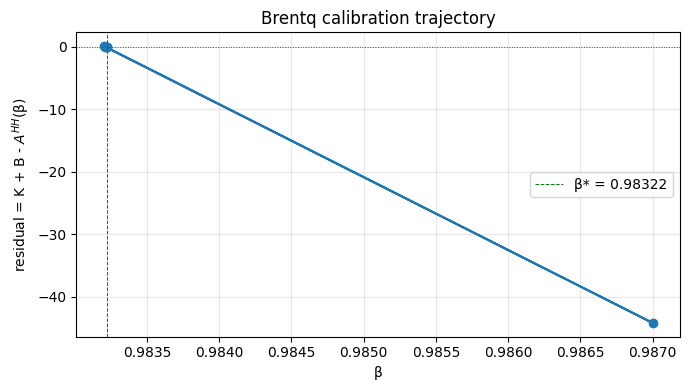

In [7]:
hist = _cache['history']
print(f'{"#":<4s}{"β":<14s}{"residual":<14s}{"A_hh":<14s}{"EGM iters":<10s}{"time(s)":<10s}')
for i, h in enumerate(hist, 1):
    print(f'{i:<4d}{h["beta"]:<14.6f}{h["residual"]:<+14.6f}{h["A_hh"]:<14.4f}{h["niter"]:<10d}{h["time"]:<10.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
betas = [h['beta'] for h in hist]
resids = [h['residual'] for h in hist]
ax.plot(betas, resids, 'o-', lw=1.5)
ax.axhline(0, color='red', lw=0.7, ls=':')
ax.axvline(beta_star, color='green', lw=0.7, ls='--', label=f'β* = {beta_star:.5f}')
ax.set_xlabel('β')
ax.set_ylabel('residual = K + B - $A^{HH}$(β)')
ax.set_title('Brentq calibration trajectory')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Save outputs

In [8]:
out_path = OUTPUT_DIR / 'calibration.npz'
np.savez(
    out_path,
    beta_calibrated=beta_star,
    cpol=cpol_star,
    dec=dec_star,
    c_fine=c_fine_star,
    dec_fine=dec_fine_star,
    G0=G0_star,
    A_hh=A_hh_star,
    K_implied=K_star,
    C_hh=C_star,
    mpc_avg=mpc_avg_star,
    mpc_fine=mpc_fine_star,
    asset_market_residual=(k_ss + b_agg_ss) - A_hh_star,
    n_brentq_evals=len(hist),
)
print(f'Saved: {out_path.resolve()}')

Saved: /Users/siyingli/github/de-Ferra2020-kz/Code/Python/output/calibration.npz
